In [1]:
from data.voirie import get_voirie
from data.filter import filter_impasses

G = get_voirie(place="2nd arrondissement, Paris, France")
G_propre = filter_impasses(G)


========== CONNECTEURS ==========
Connecteurs détectés : 165
Longueur totale      : 1.13 km



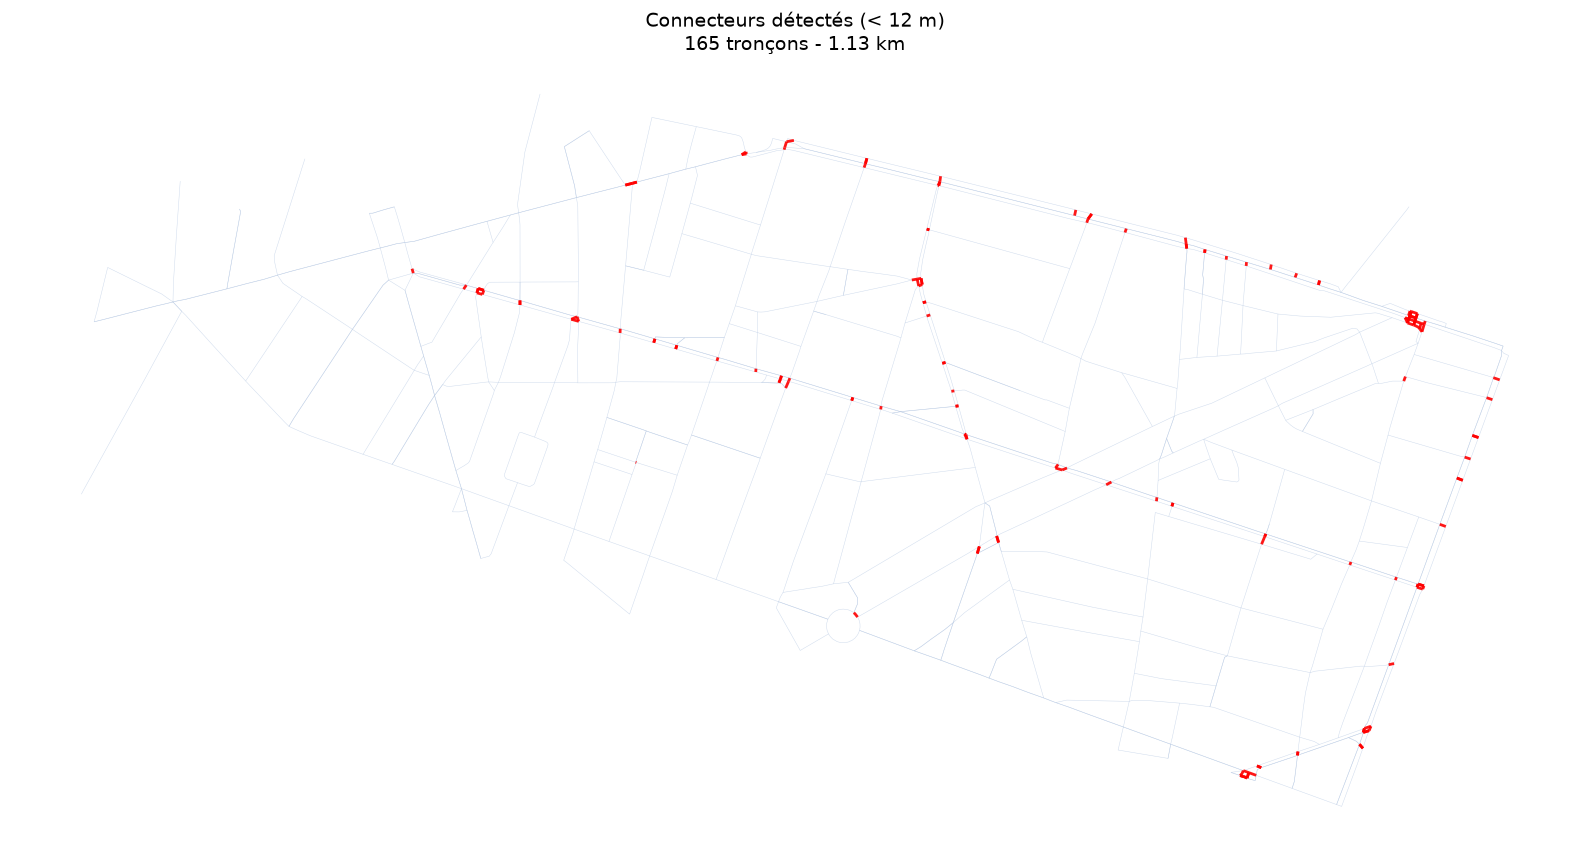

In [2]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

# ============================================================
# PARAMETRES
# ============================================================

CONNECTOR_LENGTH_M = 12

# ============================================================
# PREPARATION
# ============================================================

G_und = ox.convert.to_undirected(G_propre)

nodes_gdf, edges_gdf = ox.graph_to_gdfs(G_propre)

edges = edges_gdf.reset_index().copy()

# ============================================================
# DEGRES DES NOEUDS
# ============================================================

degree = dict(G_und.degree())

edges["deg_u"] = edges["u"].map(degree)
edges["deg_v"] = edges["v"].map(degree)

# ============================================================
# IDENTIFIANT PHYSIQUE (ignore le sens)
# ============================================================

edges["pair"] = edges.apply(
    lambda r: tuple(sorted((r["u"], r["v"]))),
    axis=1
)

# ============================================================
# BRIDGES (arêtes critiques)
# ============================================================

bridges = {
    tuple(sorted(edge))
    for edge in nx.bridges(G_und)
}

edges["is_bridge"] = edges["pair"].isin(bridges)

# ============================================================
# CONNECTEURS
# ============================================================

edges["is_connector"] = (
    (edges["length"] < CONNECTOR_LENGTH_M)
    & (edges["deg_u"] >= 3)
    & (edges["deg_v"] >= 3)
    & (~edges["is_bridge"])
)

# ============================================================
# COUVERTURE
# ============================================================

edges["mandatory_cover"] = ~edges["is_connector"]

# ============================================================
# STATISTIQUES
# ============================================================

nb_connectors = edges["is_connector"].sum()

km_connectors = (
    edges.loc[edges["is_connector"], "length"]
    .sum()
    / 1000
)

print()
print("========== CONNECTEURS ==========")
print(f"Connecteurs détectés : {nb_connectors:,}")
print(f"Longueur totale      : {km_connectors:.2f} km")
print("=================================")
print()

# ============================================================
# VISUALISATION
# ============================================================

connectors_gdf = (
    edges[edges["is_connector"]]
    .set_index(["u", "v", "key"])
)

fig, ax = plt.subplots(
    figsize=(16, 16),
    facecolor="white"
)

# Réseau complet
edges_gdf.plot(
    ax=ax,
    color="#AFC3E0",
    linewidth=0.35,
    alpha=0.6,
)

# Connecteurs
connectors_gdf.plot(
    ax=ax,
    color="red",
    linewidth=2.0,
    alpha=0.9,
)

ax.set_title(
    f"Connecteurs détectés (< {CONNECTOR_LENGTH_M} m)\n"
    f"{nb_connectors:,} tronçons - {km_connectors:.2f} km",
    fontsize=14,
)

ax.set_axis_off()

plt.tight_layout()
plt.show()